# EDA-11 | Deliverable 1 — Phase 1
# Renewable Energy Infrastructure Growth Monitor
## Exploratory Data Analysis · Regional Growth Identification · Dataset Documentation

---

## Assignment Context

**Task ID:** EDA-11 — Renewable Energy Infrastructure Growth Monitor  
**Phase:** 1 of 2 (Phase 2 = Forecasting Notebook)

**Objectives this notebook fulfils:**
- ✅ Track capacity growth of Solar, Wind, Hydro, and Biomass facilities globally  
- ✅ Identify regions with rapid green energy growth  
- ✅ Document dataset structure (columns, dtypes, nulls, coverage)  
- ✅ Produce `regional_growth_summary.csv` — the primary dataset deliverable  
- ✅ Produce all EDA visualisations (14 plots, saved as PNG)

**Data Sources Used:**
- **IRENA** renewable capacity CSV — country-level installed capacity (MW) by year and source  
- **Global Wind Atlas (GWA)** — wind speed at 100m per country (enrichment layer)  
- **NREL Solar Resource API** — solar irradiance data availability flag per country  

**Key Features in Dataset:** country, iso3, region, sub_region, year, source_type, capacity_mw, capacity_change_mw, growth_rate_pct, gwa_wind_speed_100m, has_nrel_data

---

**Sections:**
1. Setup & Configuration  
2. Data Loading & Quality Audit  
3. Global Capacity Trends (Plots 1–3)  
4. Country-Level Snapshot Analysis (Plots 4–5)  
5. Regional Breakdown (Plot 6)  
6. Growth Rate Analysis (Plots 7–9)  
7. External Data Enrichment Analysis — GWA & NREL (Plots 10–12)  
8. CAGR Computation & Rapid Growth Identification (Plots 13–14)  
9. Dataset Export — `regional_growth_summary.csv`  
10. Key Findings Summary

---
## Section 1 — Setup & Configuration

All libraries are auto-installed if missing, so this notebook runs cleanly on a fresh Colab or Jupyter environment.

The **configuration block** (bottom of this section) is the only block you need to edit. Change `INPUT_PATH` to point to your enriched CSV. All thresholds and year windows are set here — nowhere else in the notebook.

In [1]:
# ── Install any missing libraries (safe to run on Colab or fresh Jupyter env)
import importlib, subprocess, sys

REQUIRED = ["pandas", "numpy", "matplotlib", "seaborn", "scipy"]

for pkg in REQUIRED:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All libraries ready.")

All libraries ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings("ignore")

# ── Global plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ── Source type colour palette (used consistently across all plots)
SOURCE_PALETTE = {
    "Solar":   "#F4A62A",
    "Wind":    "#3A86FF",
    "Hydro":   "#06A77D",
    "Biomass": "#8B4513",
}

# ── Configuration — update INPUT_PATH if your file is in a different folder
INPUT_PATH  = "renewable_infra_full_enriched.csv"   # <-- change if needed
OUTPUT_DIR  = "."                                    # saves summary CSV here
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "regional_growth_summary.csv")

# Rapid growth threshold (CAGR % — countries above this are flagged)
RAPID_GROWTH_CAGR_THRESHOLD = 15.0

# Years to use for CAGR window
CAGR_START_YEAR = 2018
CAGR_END_YEAR   = 2023

print("Configuration loaded.")

Configuration loaded.


---
## Section 2 — Data Loading & Quality Audit

**What happens here:**  
1. Load the enriched CSV (`renewable_infra_full_enriched.csv`) — the output of the data extraction pipeline  
2. Normalise column names and fix dtypes  
3. Run a full column-level null audit — shows dtype, null count, null %, and unique value count for every column  
4. Print row counts by source type and region to confirm dataset balance  

**Why this matters for the assignment:** The assignment requires documenting dataset structure. The null audit is that documentation — it tells exactly which columns have missing data and how much, so downstream users of the CSV know what to expect.

In [3]:
df = pd.read_csv(INPUT_PATH, low_memory=False)

# ── Normalise column names (strip spaces, lowercase for safety)
df.columns = df.columns.str.strip()

# ── Ensure correct dtypes
df["year"]         = pd.to_numeric(df["year"], errors="coerce")
df["capacity_mw"]  = pd.to_numeric(df["capacity_mw"], errors="coerce")
df["capacity_change_mw"] = pd.to_numeric(df["capacity_change_mw"], errors="coerce")
df["growth_rate_pct"]    = pd.to_numeric(df["growth_rate_pct"], errors="coerce")

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Year range    : {int(df['year'].min())} – {int(df['year'].max())}")
print(f"Countries     : {df['country'].nunique()}")
print(f"Source types  : {sorted(df['source_type'].unique())}")
df.head(3)

Dataset shape : 13,940 rows × 39 columns
Year range    : 2000 – 2024
Countries     : 223
Source types  : ['Biomass', 'Hydro', 'Solar', 'Wind']


,region,sub_region,country,iso3,year,source_type,capacity_mw,capacity_change_mw,growth_rate_pct,data_source,...,nrel_resolution,nrel_weather_data_source,gwa_country_name,gwa_lat,gwa_lon,gwa_wind_speed_100m,has_nrel_data,has_gwa_data,nrel_relevant,gwa_relevant
0,Asia,Southern Asia,Afghanistan,AFG,2000,Hydro,191.50,NaN,NaN,IRENA,...,10.0,NSRDB SUNY METEOSAT IODC tmy,Afghanistan,34.52,69.18,4.146132,1,1,0,0
1,Asia,Southern Asia,Afghanistan,AFG,2001,Hydro,191.50,0.00,0.000000,IRENA,...,10.0,NSRDB SUNY METEOSAT IODC tmy,Afghanistan,34.52,69.18,4.146132,1,1,0,0
2,Asia,Southern Asia,Afghanistan,AFG,2002,Hydro,191.51,0.01,0.005222,IRENA,...,10.0,NSRDB SUNY METEOSAT IODC tmy,Afghanistan,34.52,69.18,4.146132,1,1,0,0


In [4]:
# ── Column-level null audit
null_summary = pd.DataFrame({
    "dtype":       df.dtypes,
    "null_count":  df.isnull().sum(),
    "null_pct":    (df.isnull().mean() * 100).round(2),
    "unique_vals": df.nunique(),
})
print("=== Column Audit ===")
print(null_summary.to_string())

=== Column Audit ===
                            dtype  null_count  null_pct  unique_vals
region                     object           0      0.00            5
sub_region                 object           0      0.00           17
country                    object           0      0.00          223
iso3                       object           0      0.00          223
year                        int64           0      0.00           25
source_type                object           0      0.00            4
capacity_mw               float64           0      0.00         6450
capacity_change_mw        float64         692      4.96         4748
growth_rate_pct           float64         740      5.31         7238
data_source                object           0      0.00            1
source_metric              object           0      0.00            1
unit                       object           0      0.00            1
last_updated               object           0      0.00            1
nrel_country_

In [5]:
# ── Records per source type
print("=== Rows per Source Type ===")
print(df["source_type"].value_counts().to_string())

print("\n=== Rows per Region ===")
print(df["region"].value_counts().to_string())

print("\n=== Capacity (MW) Summary ===")
print(df["capacity_mw"].describe().round(2).to_string())

=== Rows per Source Type ===
source_type
Hydro      4030
Solar      3940
Biomass    3095
Wind       2875

=== Rows per Region ===
region
Europe      3522
Americas    3255
Asia        3162
Africa      2952
Oceania     1049

=== Capacity (MW) Summary ===
count     13940.00
mean       3200.54
std       19347.65
min           0.00
25%           4.20
50%          66.00
75%         871.02
max      887099.80


---
## Section 3 — Global Capacity Trends

**What these three plots show:**

| Plot | What it tells you |
|---|---|
| **Plot 1 — Stacked area** | Total global installed capacity (GW) across all sources, year by year. Hydro at the bottom (oldest), Solar at the top (fastest growing). |
| **Plot 2 — Line chart** | Each source on its own line — lets you compare growth trajectories directly. Solar's exponential curve is clearly visible. |
| **Plot 3 — Percentage mix** | Same data as Plot 1 but normalised to 100%. Shows how the *share* of each source has shifted — Hydro's dominance declining as Solar and Wind grow. |

**Assignment link:** These plots directly answer "track the capacity growth of solar, wind, hydro, and biomass energy facilities globally."

In [6]:
# ── Aggregate: total global installed capacity per year per source
global_trend = (
    df.groupby(["year", "source_type"], as_index=False)["capacity_mw"]
    .sum()
)
global_trend["capacity_gw"] = global_trend["capacity_mw"] / 1000

# ── Total across all sources per year
global_total = (
    df.groupby("year", as_index=False)["capacity_mw"]
    .sum()
    .rename(columns={"capacity_mw": "total_mw"})
)
global_total["total_gw"] = global_total["total_mw"] / 1000

print("Global trend prepared.")

Global trend prepared.


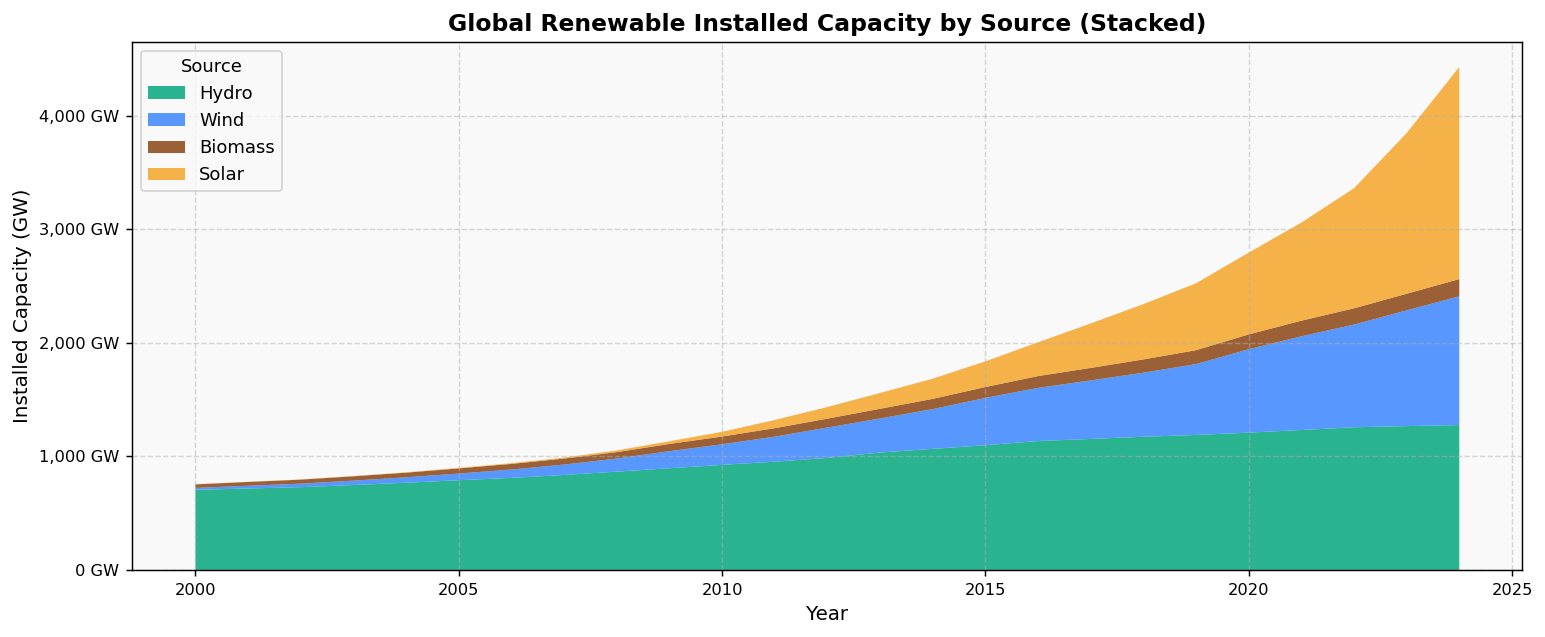

Saved: plot_01_stacked_global_capacity.png


In [7]:
# ── Plot 1: Stacked area — total global capacity by source over time
pivot = global_trend.pivot(index="year", columns="source_type", values="capacity_gw").fillna(0)
source_order = ["Hydro", "Wind", "Biomass", "Solar"]   # stack order (largest at bottom)
pivot = pivot[[s for s in source_order if s in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    pivot.index,
    [pivot[s] for s in pivot.columns],
    labels=pivot.columns,
    colors=[SOURCE_PALETTE[s] for s in pivot.columns],
    alpha=0.85,
)
ax.set_title("Global Renewable Installed Capacity by Source (Stacked)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (GW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} GW"))
ax.legend(loc="upper left", title="Source")
plt.tight_layout()
plt.savefig("plot_01_stacked_global_capacity.png", bbox_inches="tight")
plt.show()
print("Saved: plot_01_stacked_global_capacity.png")

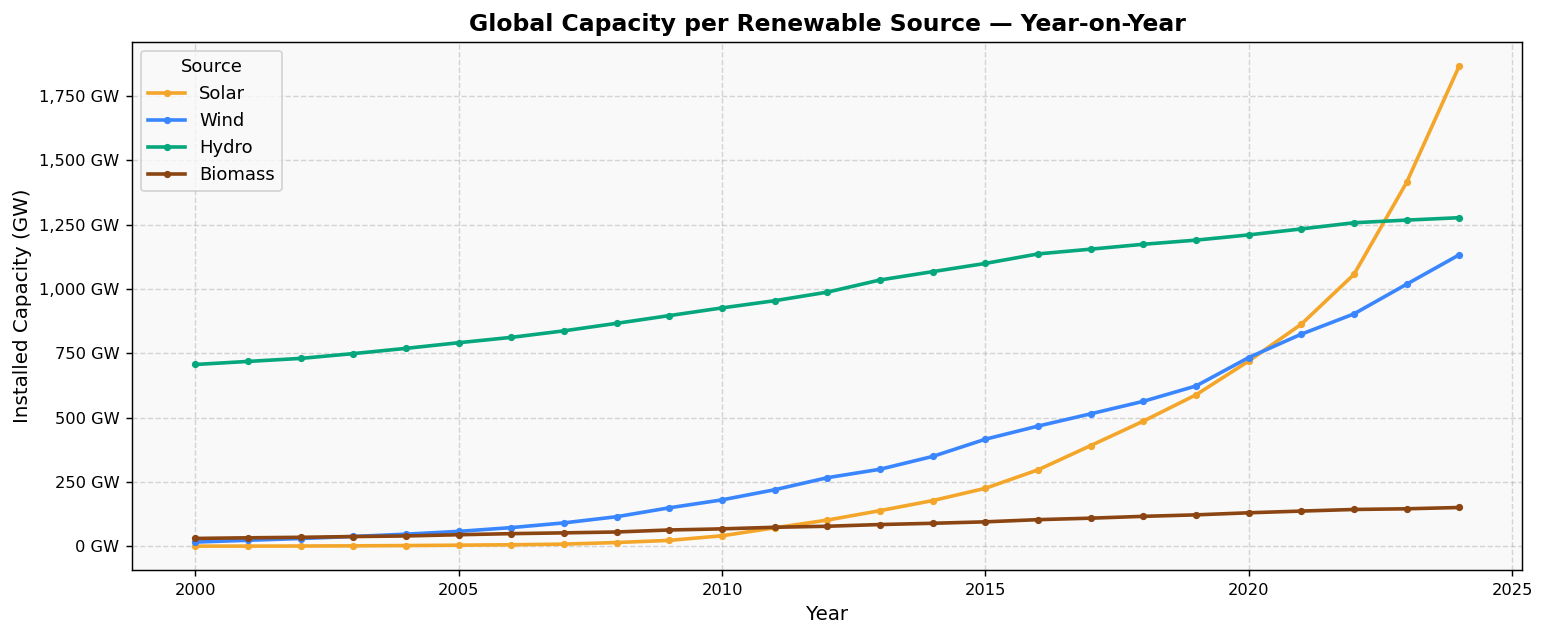

Saved: plot_02_line_source_trends.png


In [8]:
# ── Plot 2: Line chart — individual source capacity trends
fig, ax = plt.subplots(figsize=(12, 5))

for source in ["Solar", "Wind", "Hydro", "Biomass"]:
    subset = global_trend[global_trend["source_type"] == source]
    if subset.empty:
        continue
    ax.plot(
        subset["year"], subset["capacity_gw"],
        marker="o", markersize=3,
        label=source, color=SOURCE_PALETTE[source], linewidth=2
    )

ax.set_title("Global Capacity per Renewable Source — Year-on-Year", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (GW)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} GW"))
ax.legend(title="Source")
plt.tight_layout()
plt.savefig("plot_02_line_source_trends.png", bbox_inches="tight")
plt.show()
print("Saved: plot_02_line_source_trends.png")

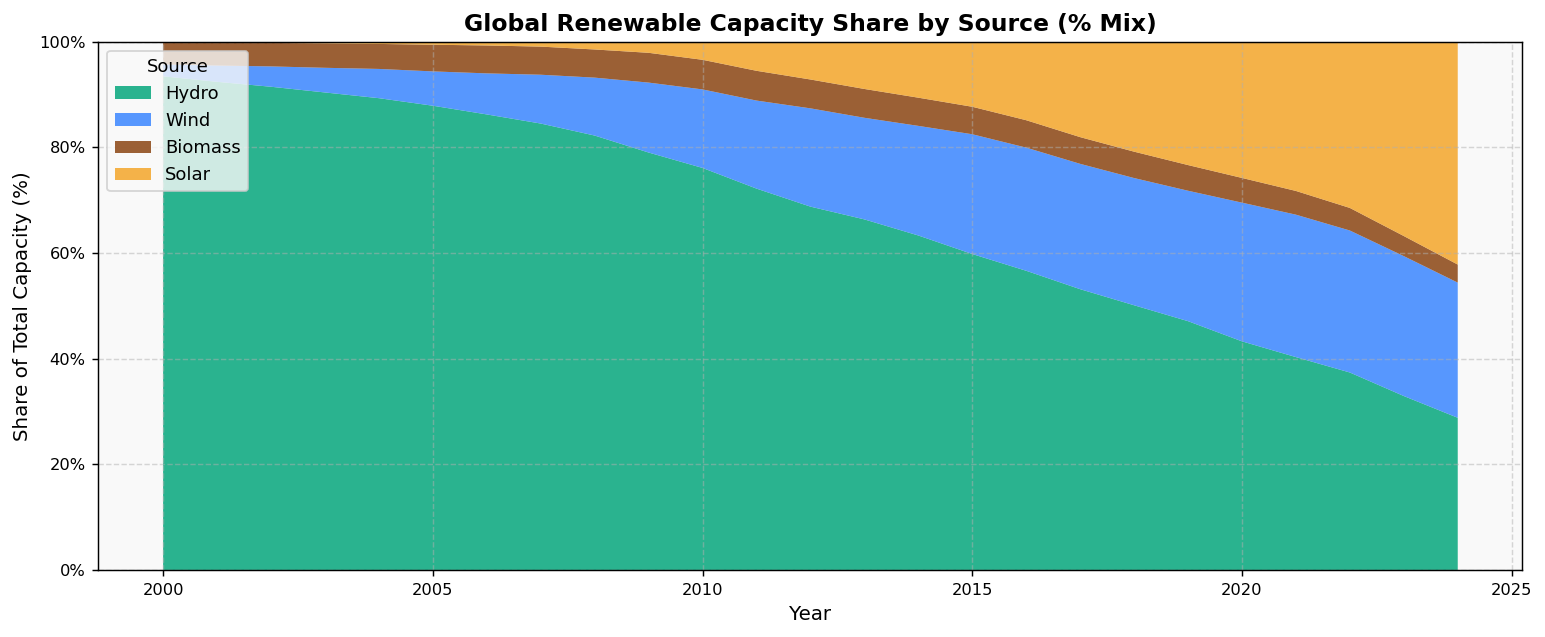

Saved: plot_03_capacity_mix_share.png


In [9]:
# ── Plot 3: Source share composition — how the mix shifted over years
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    pivot_pct.index,
    [pivot_pct[s] for s in pivot_pct.columns],
    labels=pivot_pct.columns,
    colors=[SOURCE_PALETTE[s] for s in pivot_pct.columns],
    alpha=0.85,
)
ax.set_title("Global Renewable Capacity Share by Source (% Mix)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Total Capacity (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper left", title="Source")
plt.tight_layout()
plt.savefig("plot_03_capacity_mix_share.png", bbox_inches="tight")
plt.show()
print("Saved: plot_03_capacity_mix_share.png")

---
## Section 4 — Country-Level Snapshot Analysis

**What these two plots show:**

**Plot 4 — Top 10 countries by installed capacity (latest year):**  
For each of the 4 sources, which 10 countries have the most MW installed right now? This is an absolute size comparison — large economies dominate here (China, USA, India, Germany).

**Plot 5 — Top 10 countries by average annual growth rate (last 5 years):**  
Completely different picture. This shows which countries are growing *fastest*, not which are biggest. Smaller economies with aggressive renewable policies often top this chart — this is the early warning signal for where the next wave of capacity is coming from.

**Assignment link:** "Identify regions with rapid green energy growth" — country growth rate charts are the first step before aggregating to regions.

In [10]:
# ── Use only the latest available year for snapshot comparisons
LATEST_YEAR = int(df["year"].max())
df_latest = df[df["year"] == LATEST_YEAR].copy()
print(f"Snapshot year for country comparisons: {LATEST_YEAR}")
print(f"Rows in snapshot: {len(df_latest):,}")

Snapshot year for country comparisons: 2024
Rows in snapshot: 685


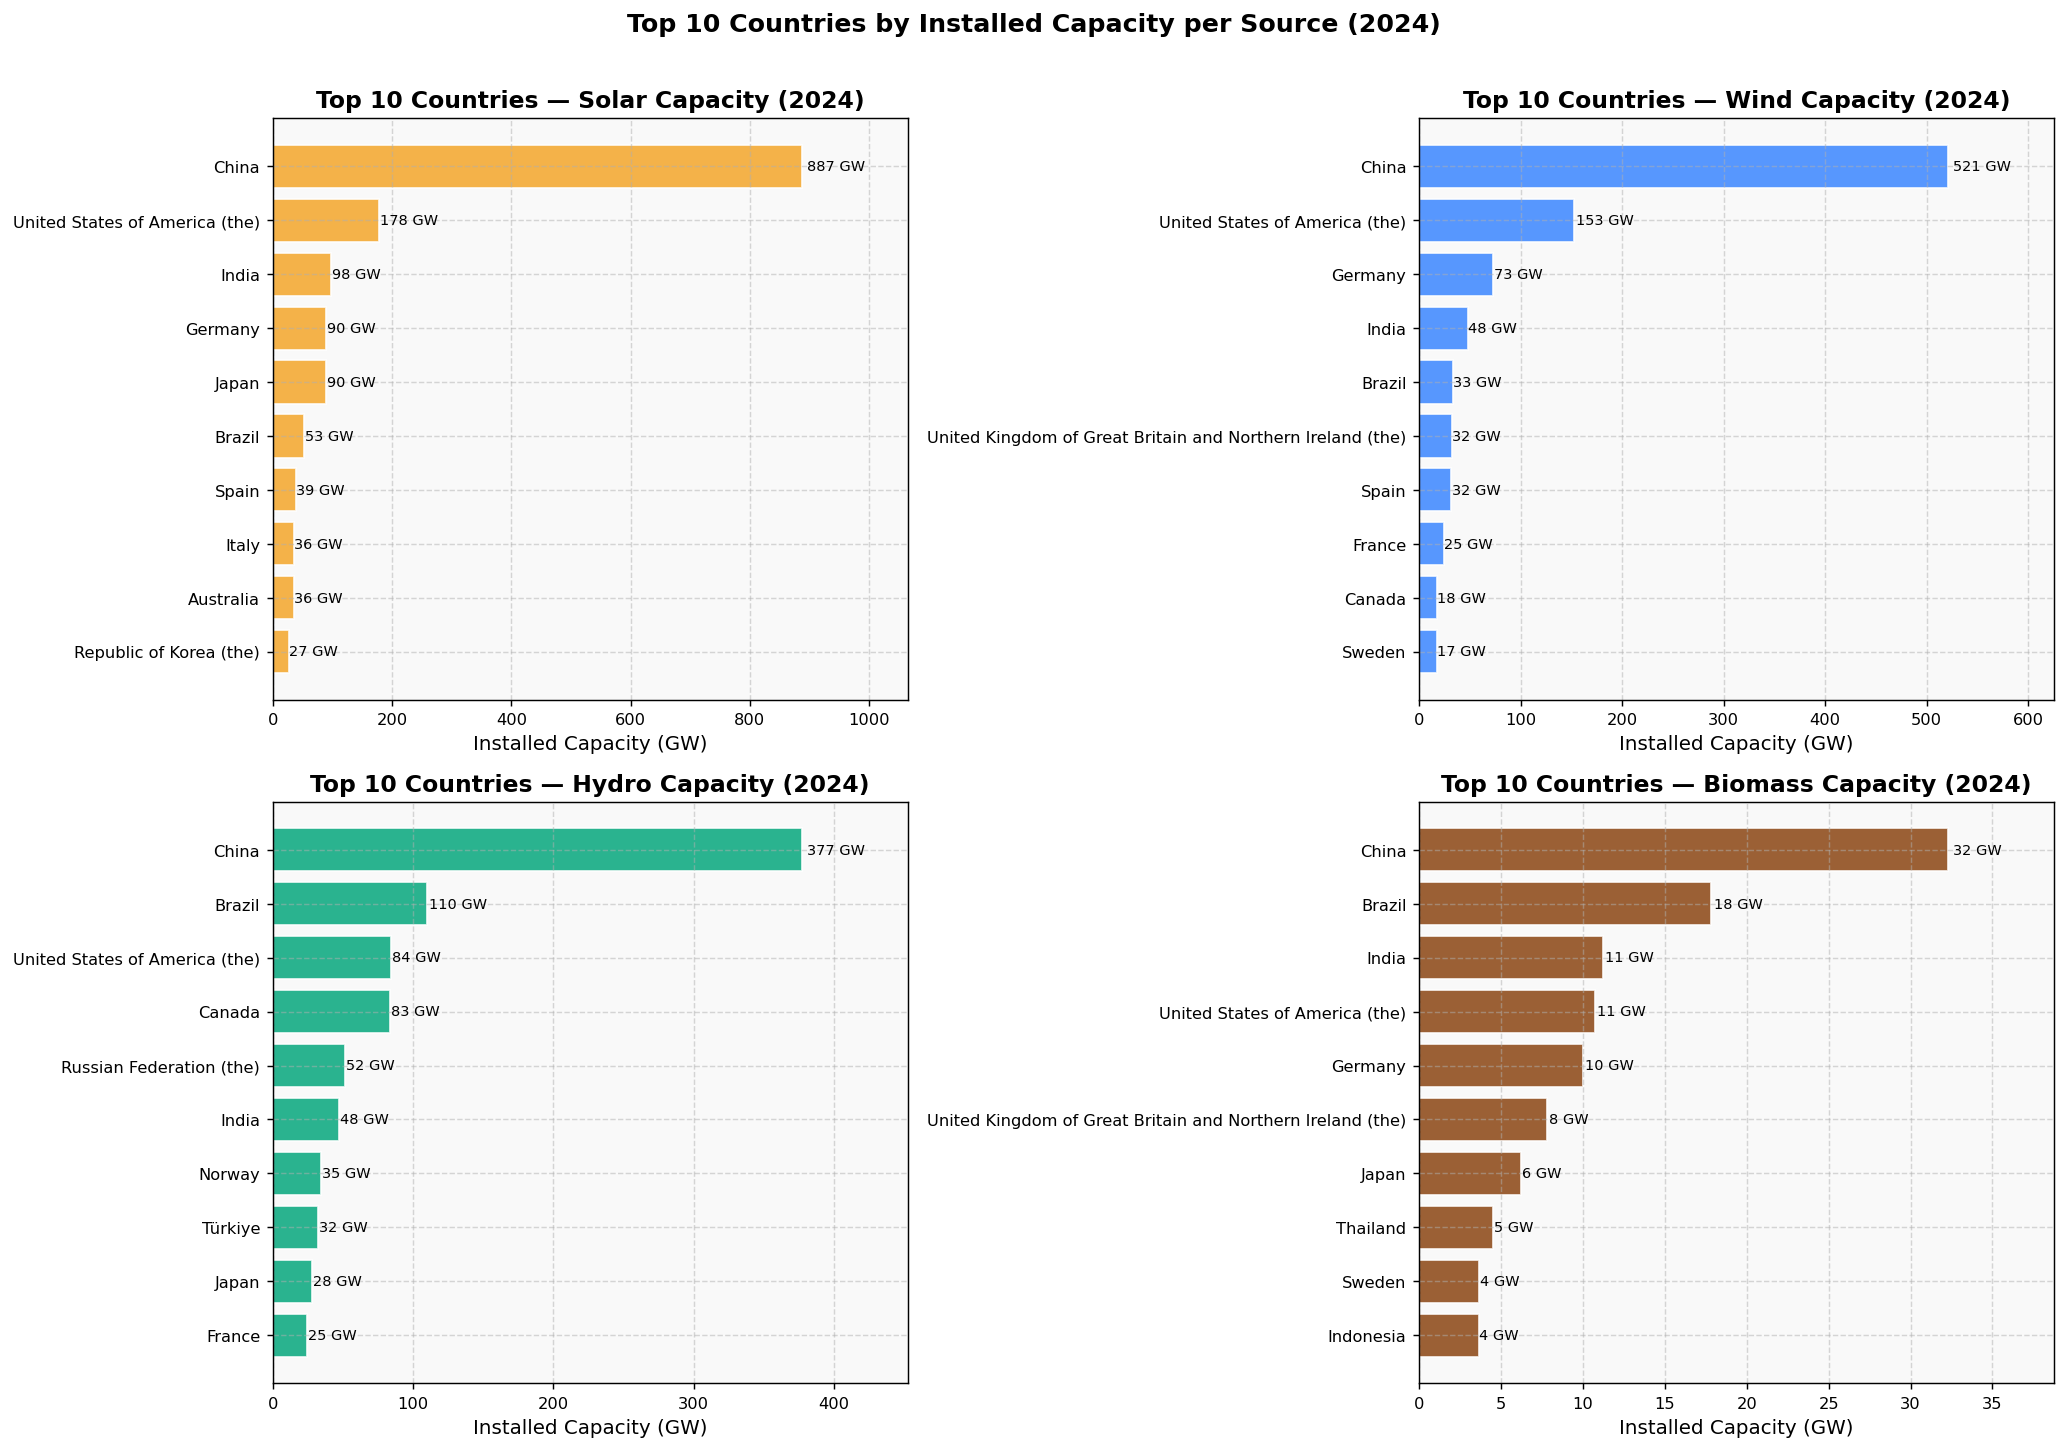

Saved: plot_04_top10_countries_by_capacity.png


In [11]:
# ── Plot 4: Top 10 countries by capacity — one subplot per source
sources = ["Solar", "Wind", "Hydro", "Biomass"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, source in enumerate(sources):
    ax = axes[i]
    top10 = (
        df_latest[df_latest["source_type"] == source]
        .groupby("country", as_index=False)["capacity_mw"]
        .sum()
        .nlargest(10, "capacity_mw")
        .sort_values("capacity_mw")
    )
    if top10.empty:
        ax.set_title(f"{source} — No data")
        continue
    bars = ax.barh(
        top10["country"],
        top10["capacity_mw"] / 1000,
        color=SOURCE_PALETTE[source],
        alpha=0.85, edgecolor="white"
    )
    # Value labels on bars
    for bar in bars:
        w = bar.get_width()
        ax.text(w + w * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{w:,.0f} GW", va="center", ha="left", fontsize=8)
    ax.set_title(f"Top 10 Countries — {source} Capacity ({LATEST_YEAR})", fontweight="bold")
    ax.set_xlabel("Installed Capacity (GW)")
    ax.set_xlim(0, top10["capacity_mw"].max() / 1000 * 1.2)

plt.suptitle(f"Top 10 Countries by Installed Capacity per Source ({LATEST_YEAR})",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_04_top10_countries_by_capacity.png", bbox_inches="tight")
plt.show()
print("Saved: plot_04_top10_countries_by_capacity.png")

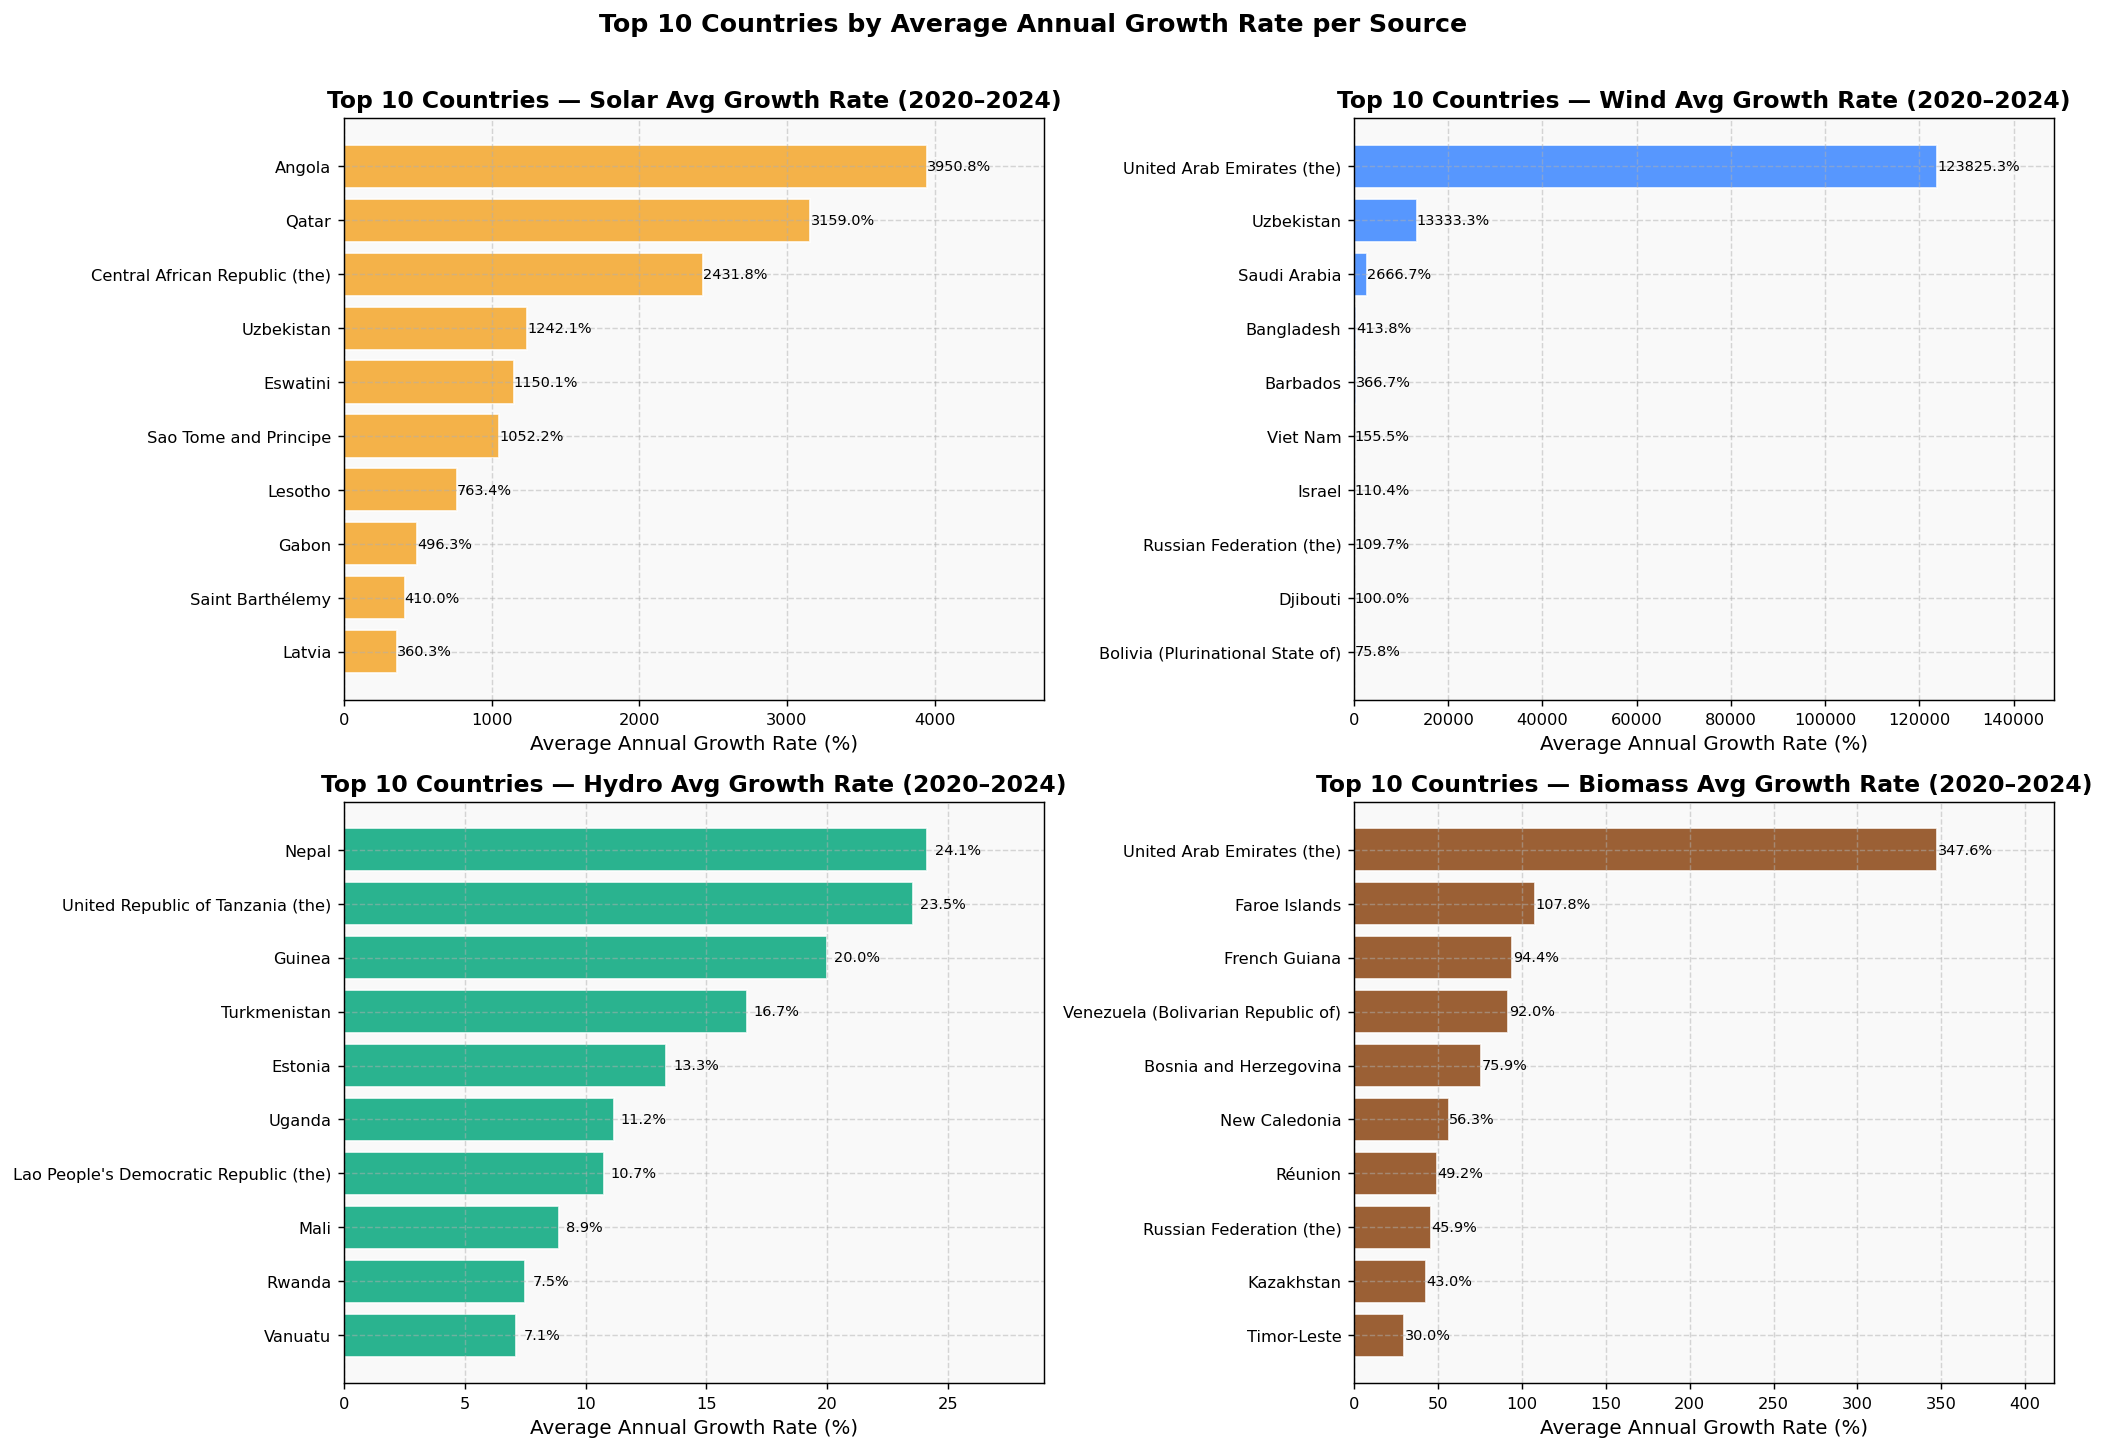

Saved: plot_05_top10_countries_by_growth.png


In [12]:
# ── Plot 5: Top 10 countries by average growth rate (last 5 years) per source
recent = df[df["year"] >= (LATEST_YEAR - 4)].copy()   # last 5 years of data

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, source in enumerate(sources):
    ax = axes[i]
    top_growth = (
        recent[recent["source_type"] == source]
        .groupby("country", as_index=False)["growth_rate_pct"]
        .mean()
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["growth_rate_pct"])
        .nlargest(10, "growth_rate_pct")
        .sort_values("growth_rate_pct")
    )
    if top_growth.empty:
        ax.set_title(f"{source} — No data")
        continue
    bars = ax.barh(
        top_growth["country"],
        top_growth["growth_rate_pct"],
        color=SOURCE_PALETTE[source],
        alpha=0.85, edgecolor="white"
    )
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{w:.1f}%", va="center", ha="left", fontsize=8)
    ax.set_title(f"Top 10 Countries — {source} Avg Growth Rate ({LATEST_YEAR-4}–{LATEST_YEAR})",
                 fontweight="bold")
    ax.set_xlabel("Average Annual Growth Rate (%)")
    ax.set_xlim(0, top_growth["growth_rate_pct"].max() * 1.2)

plt.suptitle("Top 10 Countries by Average Annual Growth Rate per Source",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_05_top10_countries_by_growth.png", bbox_inches="tight")
plt.show()
print("Saved: plot_05_top10_countries_by_growth.png")

---
## Section 5 — Regional Breakdown

**Plot 6 — Regional Capacity Heatmap (region × source):**

This heatmap aggregates all country capacities to the region level. Each cell shows total installed GW for that region-source combination in the latest available year. Darker = more capacity.

**What to look for:**
- Which regions are mature renewable markets (high Hydro or Wind)
- Which regions are just beginning Solar deployment (low values that will grow fast)
- Cross-source gaps — e.g. a region may have strong Solar but almost no Wind

**Assignment link:** This directly fulfils "identify regions with rapid green energy growth" by showing the current distribution, which combined with the growth plots above tells the full story.

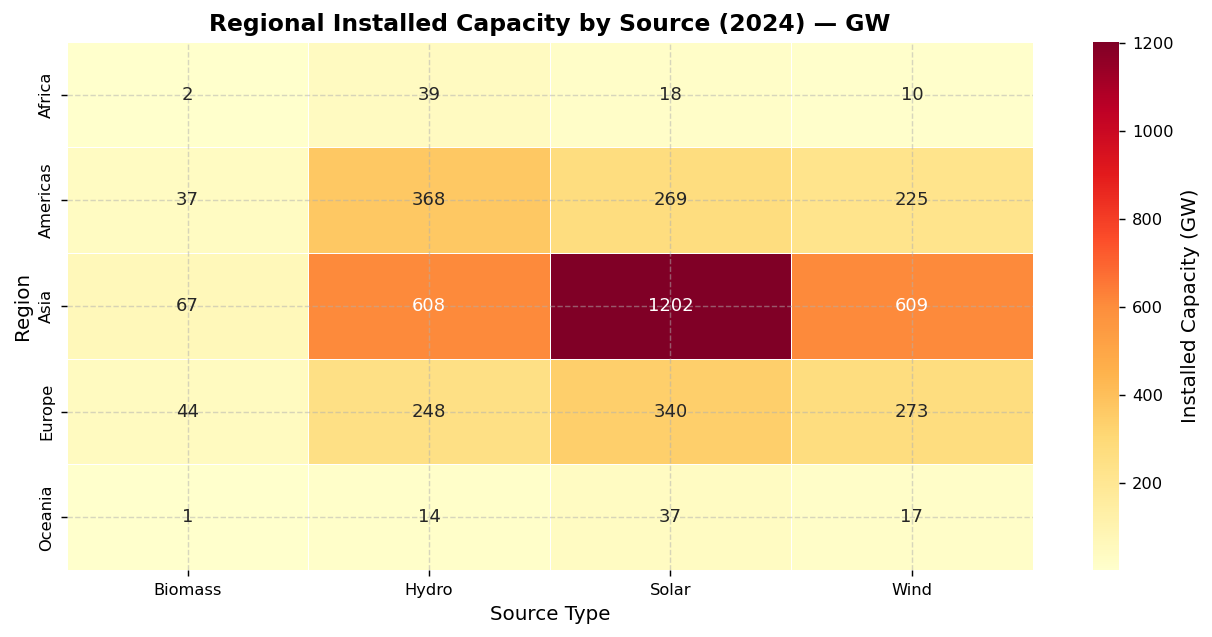

Saved: plot_06_region_source_heatmap.png


In [13]:
# ── Plot 6: Regional total capacity heatmap (region × source)
region_source = (
    df_latest.groupby(["region", "source_type"], as_index=False)["capacity_mw"]
    .sum()
    .pivot(index="region", columns="source_type", values="capacity_mw")
    .fillna(0)
)
region_source_gw = region_source / 1000

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    region_source_gw,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Installed Capacity (GW)"},
    ax=ax
)
ax.set_title(f"Regional Installed Capacity by Source ({LATEST_YEAR}) — GW", fontweight="bold")
ax.set_ylabel("Region")
ax.set_xlabel("Source Type")
plt.tight_layout()
plt.savefig("plot_06_region_source_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: plot_06_region_source_heatmap.png")

---
## Section 6 — Growth Rate Analysis

**What is growth rate?**  
`growth_rate_pct = (capacity_this_year − capacity_last_year) / capacity_last_year × 100`  
It is the year-on-year percentage change in installed capacity for a country-source pair.

**Three plots in this section:**

**Plot 7 — Histogram + KDE:** Distribution of all annual growth rates across every country and source. The shape tells you whether most countries are growing slowly (right-skewed = most near 0, a few outliers very high) or uniformly. The median line shows the typical country experience.

**Plot 8 — Box plot by source:** Same data broken down per source. Solar shows the highest median and widest spread — it has both the fastest-growing countries and the most variability. Hydro is the tightest (most mature, least variable).

**Plot 9 — Median growth trend over years:** How has the typical growth rate changed over time, per source? This answers: "is adoption accelerating or decelerating?"

**Data quality note:** Outliers above the 99th percentile are clipped before plotting to avoid axis compression from extreme values (e.g. a country going from 1 MW to 1000 MW = 99,900% growth).

In [14]:
# ── Clip extreme outliers for plotting (keep 1st–99th percentile)
gr = df["growth_rate_pct"].replace([np.inf, -np.inf], np.nan).dropna()
lo, hi = gr.quantile(0.01), gr.quantile(0.99)
gr_clipped = gr.clip(lo, hi)

print(f"Growth rate stats (clipped 1–99 pct):")
print(gr_clipped.describe().round(2).to_string())

Growth rate stats (clipped 1–99 pct):
count    13200.00
mean        32.18
std        115.60
min        -14.29
25%          0.00
50%          0.19
75%         15.28
max        911.64


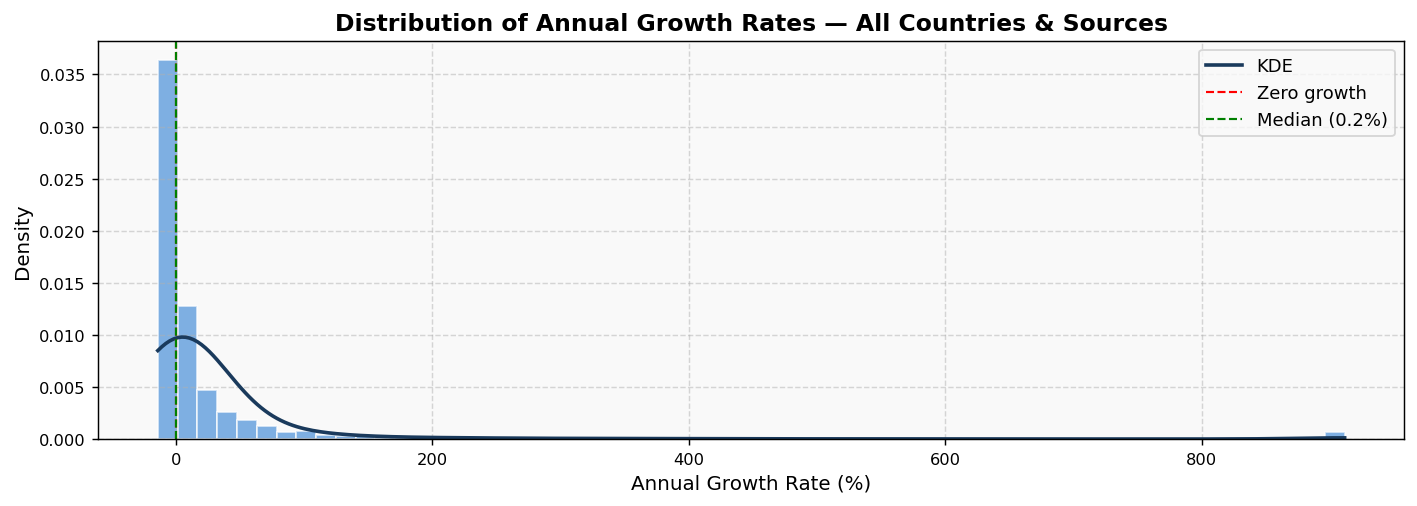

Saved: plot_07_growth_rate_histogram.png


In [15]:
# ── Plot 7: Overall growth rate histogram with KDE
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(gr_clipped, bins=60, color="#4A90D9", alpha=0.7, edgecolor="white", density=True)

from scipy.stats import gaussian_kde
kde = gaussian_kde(gr_clipped, bw_method=0.3)
x_range = np.linspace(lo, hi, 300)
ax.plot(x_range, kde(x_range), color="#1A3A5C", linewidth=2, label="KDE")

ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero growth")
ax.axvline(gr_clipped.median(), color="green", linestyle="--",
           linewidth=1.2, label=f"Median ({gr_clipped.median():.1f}%)")

ax.set_title("Distribution of Annual Growth Rates — All Countries & Sources", fontweight="bold")
ax.set_xlabel("Annual Growth Rate (%)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("plot_07_growth_rate_histogram.png", bbox_inches="tight")
plt.show()
print("Saved: plot_07_growth_rate_histogram.png")

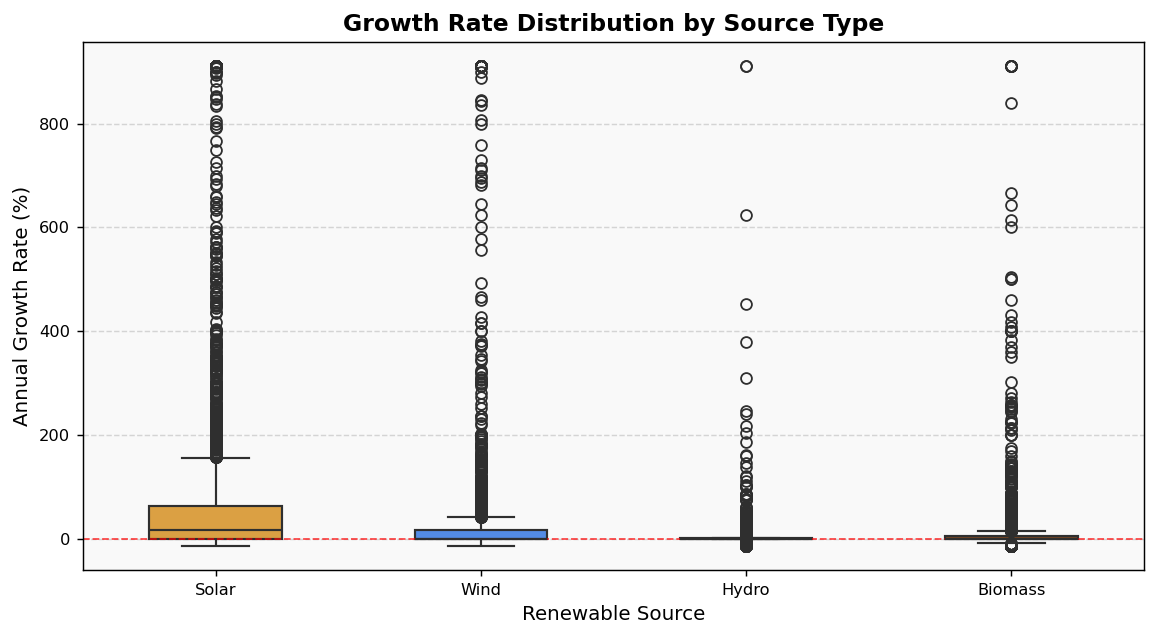

Saved: plot_08_boxplot_growth_by_source.png


In [16]:
# ── Plot 8: Box plot — growth rate per source type
df_gr = df.copy()
df_gr["growth_rate_pct"] = (
    df_gr["growth_rate_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(lo, hi)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_gr.dropna(subset=["growth_rate_pct"]),
    x="source_type", y="growth_rate_pct",
    palette=SOURCE_PALETTE,
    order=["Solar", "Wind", "Hydro", "Biomass"],
    width=0.5, linewidth=1.2,
    ax=ax
)
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Growth Rate Distribution by Source Type", fontweight="bold")
ax.set_xlabel("Renewable Source")
ax.set_ylabel("Annual Growth Rate (%)")
plt.tight_layout()
plt.savefig("plot_08_boxplot_growth_by_source.png", bbox_inches="tight")
plt.show()
print("Saved: plot_08_boxplot_growth_by_source.png")

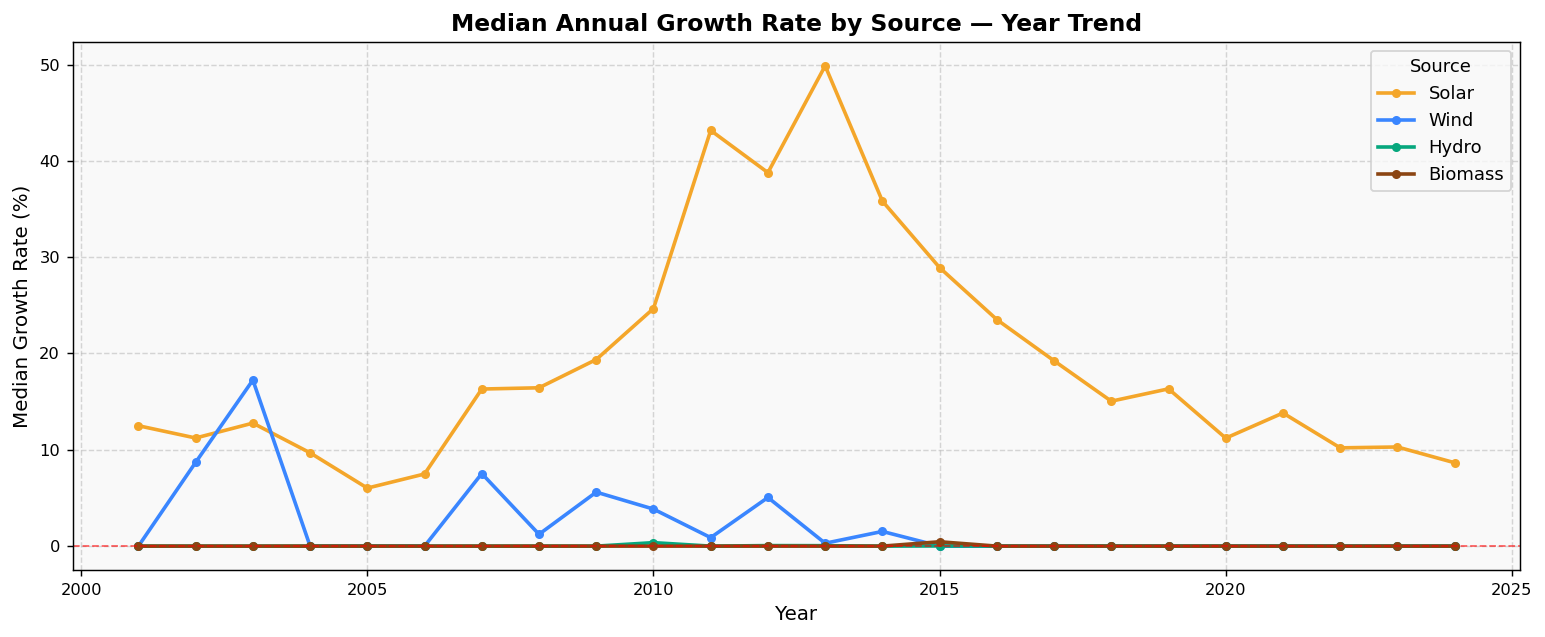

Saved: plot_09_median_growth_trend.png


In [17]:
# ── Plot 9: Growth rate trends over years — median per source
median_growth = (
    df_gr.dropna(subset=["growth_rate_pct"])
    .groupby(["year", "source_type"])["growth_rate_pct"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for source in ["Solar", "Wind", "Hydro", "Biomass"]:
    s = median_growth[median_growth["source_type"] == source]
    if s.empty:
        continue
    ax.plot(s["year"], s["growth_rate_pct"],
            marker="o", markersize=4,
            label=source, color=SOURCE_PALETTE[source], linewidth=2)

ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Median Annual Growth Rate by Source — Year Trend", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Growth Rate (%)")
ax.legend(title="Source")
plt.tight_layout()
plt.savefig("plot_09_median_growth_trend.png", bbox_inches="tight")
plt.show()
print("Saved: plot_09_median_growth_trend.png")

---
## Section 7 — External Data Enrichment Analysis (GWA & NREL)

**Assignment requirement:** "IRENA renewable capacity CSV downloads, Global Wind Atlas data scraping, NREL solar resource data API."

This section validates and uses those two enrichment layers:

**Sub-section 7A — Global Wind Atlas (GWA) enrichment:**  
Does wind speed actually correlate with wind capacity growth rate? If a country has excellent wind resources (high GWA score at 100m hub height), does that translate to faster capacity growth? Pearson correlation + scatter + trendline answers this. A significant positive correlation would validate that resource quality is a driver of adoption.

**Sub-section 7B — NREL solar resource data enrichment:**  
Countries that had NREL solar irradiance data available — do they show higher solar growth rates? NREL data availability is a proxy for data infrastructure quality and international research attention. Mann-Whitney U test checks whether the difference is statistically significant.

**Sub-section 7C — Numeric correlation matrix:**  
Full correlation matrix across capacity_mw, capacity_change_mw, growth_rate_pct, and gwa_wind_speed_100m. Heatmap with Pearson r values. Tells you which features are linearly related — useful for feature selection in the Phase 2 forecasting notebook.

Wind Speed vs Growth Rate — Pearson r = -0.026, p-value = 0.1841


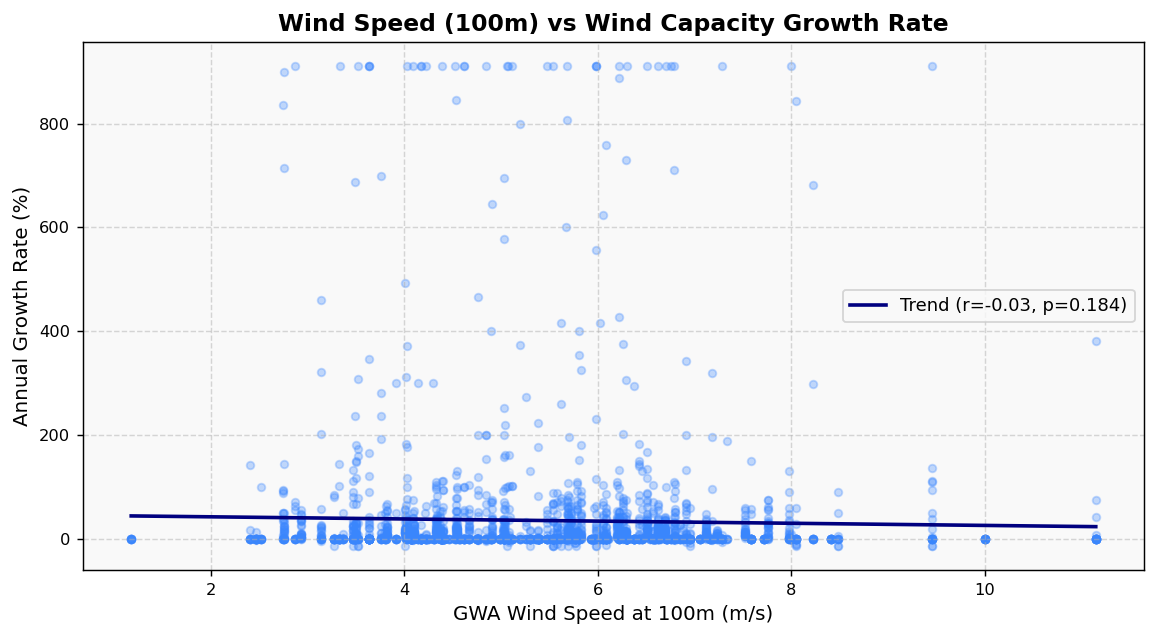

Saved: plot_10_wind_speed_vs_growth.png


In [18]:
# ── 6A: Wind speed vs wind capacity growth rate
wind_df = df[
    (df["source_type"] == "Wind") &
    (df["gwa_relevant"] == 1)
].copy()

wind_df["gwa_wind_speed_100m"] = pd.to_numeric(wind_df["gwa_wind_speed_100m"], errors="coerce")
wind_corr = wind_df.dropna(subset=["gwa_wind_speed_100m", "growth_rate_pct"]).copy()
wind_corr["growth_rate_pct"] = wind_corr["growth_rate_pct"].clip(lo, hi)

if len(wind_corr) > 10:
    r, p = stats.pearsonr(wind_corr["gwa_wind_speed_100m"], wind_corr["growth_rate_pct"])
    print(f"Wind Speed vs Growth Rate — Pearson r = {r:.3f}, p-value = {p:.4f}")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(wind_corr["gwa_wind_speed_100m"], wind_corr["growth_rate_pct"],
               alpha=0.3, s=18, color=SOURCE_PALETTE["Wind"])
    # Trend line
    m, b = np.polyfit(wind_corr["gwa_wind_speed_100m"], wind_corr["growth_rate_pct"], 1)
    x_fit = np.linspace(wind_corr["gwa_wind_speed_100m"].min(),
                        wind_corr["gwa_wind_speed_100m"].max(), 100)
    ax.plot(x_fit, m * x_fit + b, color="navy", linewidth=2,
            label=f"Trend (r={r:.2f}, p={p:.3f})")
    ax.set_title("Wind Speed (100m) vs Wind Capacity Growth Rate", fontweight="bold")
    ax.set_xlabel("GWA Wind Speed at 100m (m/s)")
    ax.set_ylabel("Annual Growth Rate (%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("plot_10_wind_speed_vs_growth.png", bbox_inches="tight")
    plt.show()
    print("Saved: plot_10_wind_speed_vs_growth.png")
else:
    print("Not enough wind data with GWA enrichment for correlation analysis.")

Solar growth — WITH NREL data    : median = 17.86%, n = 3552
Solar growth — WITHOUT NREL data : median = 8.84%, n = 122
Mann-Whitney U test p-value = 0.0694


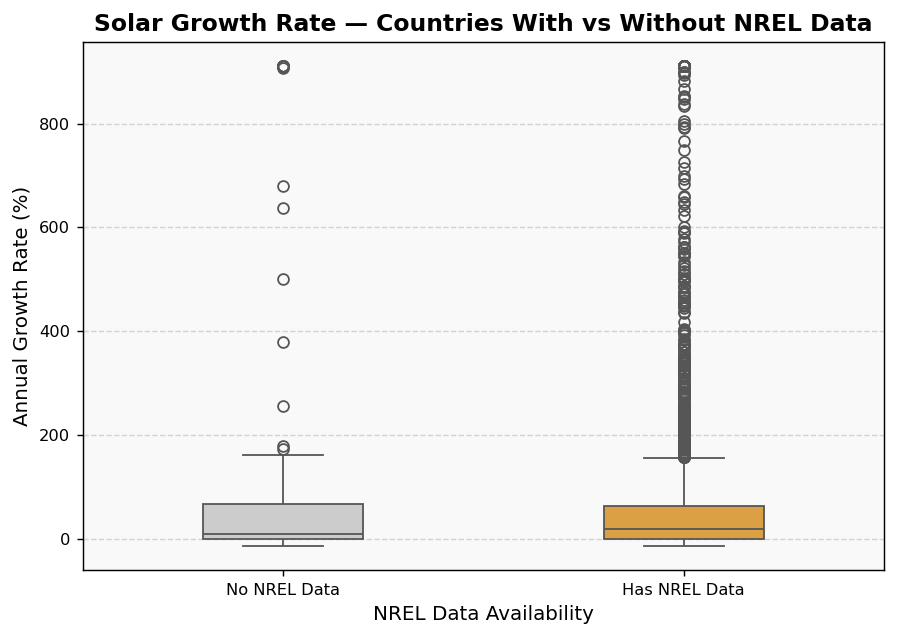

Saved: plot_11_nrel_vs_solar_growth.png


In [19]:
# ── 6B: NREL data availability vs solar capacity growth
solar_df = df[
    (df["source_type"] == "Solar") &
    (df["nrel_relevant"] == 1)
].copy()

solar_df["has_nrel_data"] = pd.to_numeric(solar_df["has_nrel_data"], errors="coerce")
solar_corr = solar_df.dropna(subset=["has_nrel_data", "growth_rate_pct"]).copy()
solar_corr = solar_corr[solar_corr["has_nrel_data"].isin([0, 1])]
solar_corr["growth_rate_pct"] = solar_corr["growth_rate_pct"].clip(lo, hi)

# ── FIX: convert to string so seaborn palette keys match exactly
solar_corr["nrel_label"] = solar_corr["has_nrel_data"].astype(int).map(
    {0: "No NREL Data", 1: "Has NREL Data"}
)

if len(solar_corr) > 10:
    with_nrel    = solar_corr[solar_corr["nrel_label"] == "Has NREL Data"]["growth_rate_pct"]
    without_nrel = solar_corr[solar_corr["nrel_label"] == "No NREL Data"]["growth_rate_pct"]

    print(f"Solar growth — WITH NREL data    : median = {with_nrel.median():.2f}%, n = {len(with_nrel)}")
    print(f"Solar growth — WITHOUT NREL data : median = {without_nrel.median():.2f}%, n = {len(without_nrel)}")

    if len(with_nrel) > 1 and len(without_nrel) > 1:
        t_stat, p_val = stats.mannwhitneyu(with_nrel, without_nrel, alternative="two-sided")
        print(f"Mann-Whitney U test p-value = {p_val:.4f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=solar_corr,
        x="nrel_label", y="growth_rate_pct",
        order=["No NREL Data", "Has NREL Data"],          # explicit order
        palette={"No NREL Data": "#CCCCCC", "Has NREL Data": SOURCE_PALETTE["Solar"]},
        width=0.4, ax=ax
    )
    ax.set_title("Solar Growth Rate — Countries With vs Without NREL Data", fontweight="bold")
    ax.set_xlabel("NREL Data Availability")
    ax.set_ylabel("Annual Growth Rate (%)")
    plt.tight_layout()
    plt.savefig("plot_11_nrel_vs_solar_growth.png", bbox_inches="tight")
    plt.show()
    print("Saved: plot_11_nrel_vs_solar_growth.png")
else:
    print("Not enough solar data with NREL enrichment for comparison.")

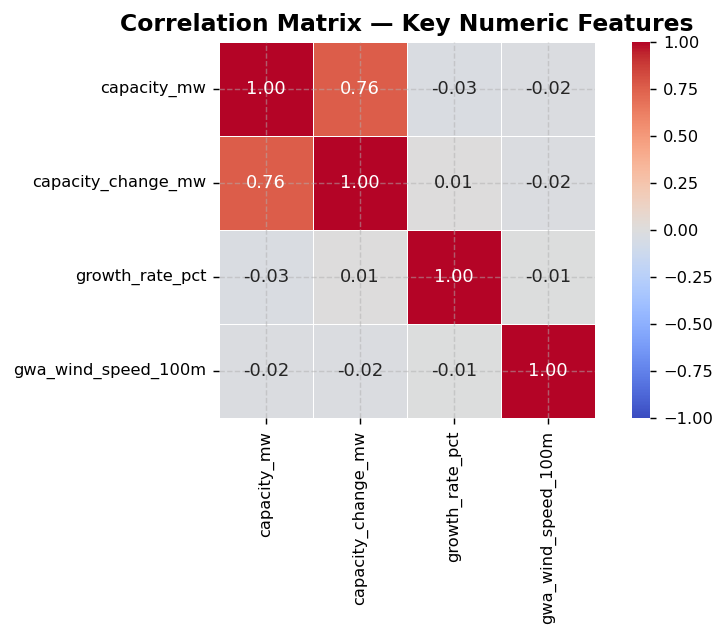

Saved: plot_12_correlation_matrix.png


In [20]:
# ── 6C: Numeric correlation matrix (capacity, growth, wind speed)
numeric_cols = ["capacity_mw", "capacity_change_mw", "growth_rate_pct", "gwa_wind_speed_100m"]
corr_df = df[numeric_cols].copy()
corr_df["gwa_wind_speed_100m"] = pd.to_numeric(corr_df["gwa_wind_speed_100m"], errors="coerce")
corr_df["growth_rate_pct"] = corr_df["growth_rate_pct"].clip(lo, hi)
corr_matrix = corr_df.dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax
)
ax.set_title("Correlation Matrix — Key Numeric Features", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_12_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Saved: plot_12_correlation_matrix.png")

---
## Section 8 — CAGR Computation & Rapid Growth Identification

**What is CAGR?**  
CAGR = Compound Annual Growth Rate = `((end_capacity / start_capacity) ^ (1/n_years) − 1) × 100`

Unlike a single-year growth rate, CAGR smooths over the full window and gives a fair comparison between countries with different data noise levels.

**Window used:** `CAGR_START_YEAR` to `CAGR_END_YEAR` (configurable at top, default 2018–2023 = 5 years)

**Rapid growth flag:** Any country-source pair with CAGR ≥ `RAPID_GROWTH_CAGR_THRESHOLD` (default 15%) is flagged `is_rapid_growth = 1`. This flag is exported to the summary CSV and used in Phase 2 as a feature.

**Plot 13 — Top 15 CAGR entries:** Which country-source pairs grew fastest over the window? Colour-coded by source type. Red threshold line marks the rapid growth boundary.

**Plot 14 — CAGR violin by source:** Distribution of CAGR across all countries, per source. The violin shape shows where most countries cluster and how many outliers exist above the rapid growth threshold.

**Safe CAGR function:** If either start or end capacity is ≤ 0 (country had no capacity yet), CAGR is set to NaN rather than dividing by zero or computing a meaningless number.

In [21]:
# ── Compute 5-year CAGR per country per source
# CAGR = ((end_capacity / start_capacity) ^ (1/n_years)) - 1

start = df[df["year"] == CAGR_START_YEAR][["country", "iso3", "region", "sub_region",
                                            "source_type", "capacity_mw"]].copy()
end   = df[df["year"] == CAGR_END_YEAR][["country", "iso3", "region", "sub_region",
                                           "source_type", "capacity_mw"]].copy()

start = start.rename(columns={"capacity_mw": "capacity_start"})
end   = end.rename(columns={"capacity_mw": "capacity_end"})

cagr_df = start.merge(end, on=["country", "iso3", "region", "sub_region", "source_type"])

n_years = CAGR_END_YEAR - CAGR_START_YEAR

def safe_cagr(row):
    if row["capacity_start"] <= 0 or row["capacity_end"] <= 0:
        return np.nan
    return ((row["capacity_end"] / row["capacity_start"]) ** (1 / n_years) - 1) * 100

cagr_df["cagr_pct"] = cagr_df.apply(safe_cagr, axis=1)

print(f"CAGR computed for {len(cagr_df):,} country-source pairs ({CAGR_START_YEAR}→{CAGR_END_YEAR}).")
print(cagr_df["cagr_pct"].describe().round(2).to_string())

CAGR computed for 666 country-source pairs (2018→2023).
count    666.00
mean      16.11
std       31.87
min      -50.89
25%        0.00
50%        3.02
75%       19.54
max      271.29


In [22]:
# ── Flag rapid growth countries
cagr_df["is_rapid_growth"] = (cagr_df["cagr_pct"] >= RAPID_GROWTH_CAGR_THRESHOLD).astype(int)

rapid = cagr_df[cagr_df["is_rapid_growth"] == 1].sort_values("cagr_pct", ascending=False)
print(f"Countries with CAGR >= {RAPID_GROWTH_CAGR_THRESHOLD}%: {len(rapid)}")
print("\nTop 20 rapid growth entries:")
print(rapid[["country", "source_type", "capacity_start", "capacity_end", "cagr_pct"]]
      .head(20).round(2).to_string(index=False))

Countries with CAGR >= 15.0%: 193

Top 20 rapid growth entries:
                                       country source_type  capacity_start  capacity_end  cagr_pct
                                        Angola       Solar            0.44        310.46    271.29
China, Hong Kong Special Administrative Region       Solar            1.00        333.10    219.53
                                      Eswatini       Solar            0.13         27.95    192.74
                                       Albania       Solar            1.00        206.73    190.46
                                      Viet Nam       Solar          104.93      18587.35    181.62
                                        Latvia       Solar            1.96        319.00    176.89
                                         Qatar       Solar            5.10        805.10    175.20
                                    Uzbekistan       Solar            3.51        474.51    166.80
                Central African Republic (the

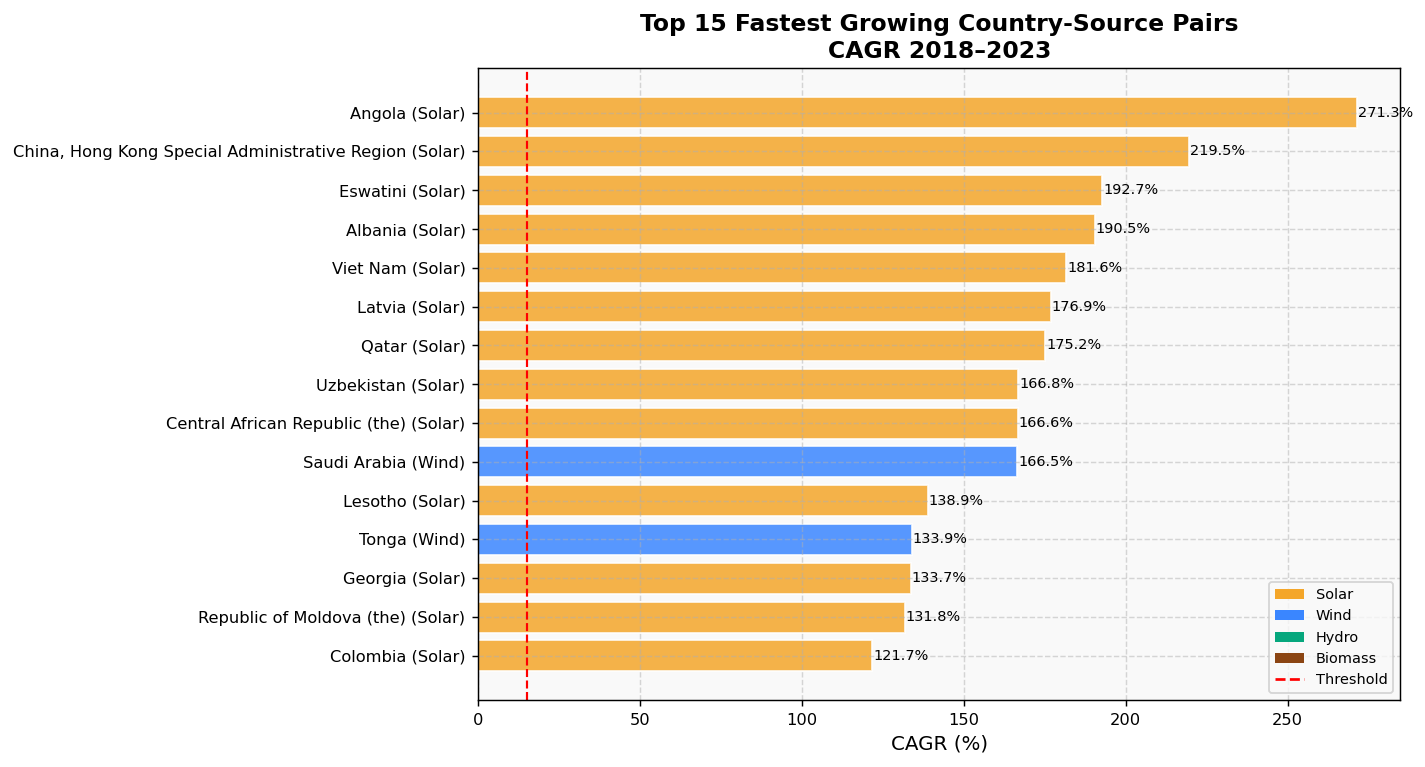

Saved: plot_13_top_rapid_growth.png


In [23]:
# ── Plot 13: Top 15 rapid growth entries (CAGR) — all sources combined
top_rapid = cagr_df.dropna(subset=["cagr_pct"]).nlargest(15, "cagr_pct").sort_values("cagr_pct")
top_rapid["label"] = top_rapid["country"] + " (" + top_rapid["source_type"] + ")"

fig, ax = plt.subplots(figsize=(11, 6))
colors = [SOURCE_PALETTE.get(s, "#888888") for s in top_rapid["source_type"]]
bars = ax.barh(top_rapid["label"], top_rapid["cagr_pct"], color=colors, alpha=0.85, edgecolor="white")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}%", va="center", ha="left", fontsize=8)

ax.axvline(RAPID_GROWTH_CAGR_THRESHOLD, color="red", linestyle="--",
           linewidth=1.2, label=f"Threshold ({RAPID_GROWTH_CAGR_THRESHOLD}%)")
ax.set_title(f"Top 15 Fastest Growing Country-Source Pairs\nCAGR {CAGR_START_YEAR}–{CAGR_END_YEAR}",
             fontweight="bold")
ax.set_xlabel("CAGR (%)")

# Legend for source colors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=s) for s, c in SOURCE_PALETTE.items()]
legend_handles.append(plt.Line2D([0], [0], color="red", linestyle="--", label=f"Threshold"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("plot_13_top_rapid_growth.png", bbox_inches="tight")
plt.show()
print("Saved: plot_13_top_rapid_growth.png")

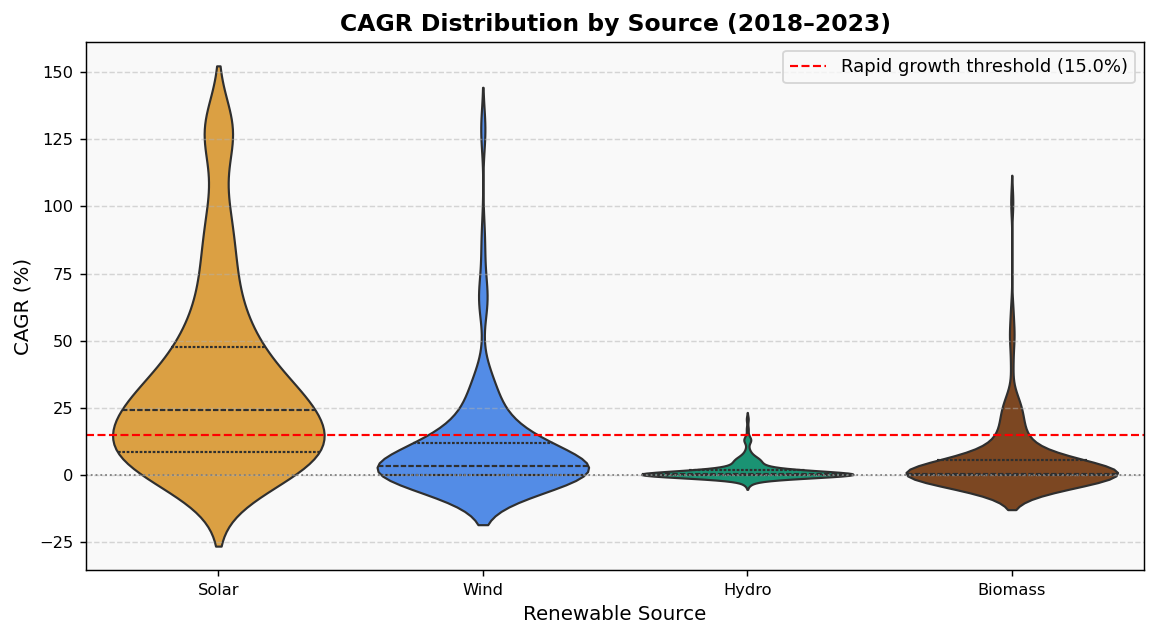

Saved: plot_14_cagr_violin_by_source.png


In [24]:
# ── Plot 14: CAGR distribution by source — violin plot
cagr_plot = cagr_df.dropna(subset=["cagr_pct"]).copy()
cagr_plot["cagr_pct"] = cagr_plot["cagr_pct"].clip(
    cagr_plot["cagr_pct"].quantile(0.02),
    cagr_plot["cagr_pct"].quantile(0.98)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=cagr_plot, x="source_type", y="cagr_pct",
    palette=SOURCE_PALETTE, order=["Solar", "Wind", "Hydro", "Biomass"],
    inner="quartile", linewidth=1.2, ax=ax
)
ax.axhline(RAPID_GROWTH_CAGR_THRESHOLD, color="red", linestyle="--",
           linewidth=1.2, label=f"Rapid growth threshold ({RAPID_GROWTH_CAGR_THRESHOLD}%)")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_title(f"CAGR Distribution by Source ({CAGR_START_YEAR}–{CAGR_END_YEAR})", fontweight="bold")
ax.set_xlabel("Renewable Source")
ax.set_ylabel("CAGR (%)")
ax.legend()
plt.tight_layout()
plt.savefig("plot_14_cagr_violin_by_source.png", bbox_inches="tight")
plt.show()
print("Saved: plot_14_cagr_violin_by_source.png")

---
## Section 9 — Dataset Export: `regional_growth_summary.csv`

**This is the primary deliverable of Phase 1.**

The summary CSV is built by merging three computed tables:

| Table | What it adds |
|---|---|
| `latest_cap` | Current installed capacity (MW) in the latest available year, per country-source |
| `avg_growth` | Average annual growth rate over the last 5 years, per country-source |
| `cagr_cols` | CAGR (%), start/end capacity, rapid growth flag — from the 5-year CAGR window |

**One row = one country-source pair.**

**Columns in the output CSV:**
- `country`, `iso3`, `region`, `sub_region`, `source_type` — identifiers
- `capacity_mw_{LATEST_YEAR}` — current installed capacity
- `avg_growth_rate_pct_5yr` — 5-year average annual growth rate
- `capacity_mw_{CAGR_START_YEAR}`, `capacity_mw_{CAGR_END_YEAR}` — window endpoints
- `cagr_pct` — compound annual growth rate over the window
- `is_rapid_growth` — binary flag (1 = CAGR ≥ threshold)

**This CSV feeds directly into Notebook 2 (Phase 2)** as a supplementary reference for regional classification.

In [25]:
# ── Build regional_growth_summary.csv
# One row per country-source pair with: region, capacity in latest year,
# avg annual growth rate (last 5 yrs), CAGR (5yr window), rapid growth flag

# Latest year capacity
latest_cap = (
    df_latest.groupby(["country", "iso3", "region", "sub_region", "source_type"],
                       as_index=False)["capacity_mw"]
    .sum()
    .rename(columns={"capacity_mw": f"capacity_mw_{LATEST_YEAR}"})
)

# Avg annual growth (last 5 years)
avg_growth = (
    recent.groupby(["country", "iso3", "source_type"], as_index=False)["growth_rate_pct"]
    .mean()
    .replace([np.inf, -np.inf], np.nan)
    .rename(columns={"growth_rate_pct": "avg_growth_rate_pct_5yr"})
)

# CAGR
cagr_cols = cagr_df[["country", "iso3", "source_type",
                       "capacity_start", "capacity_end",
                       "cagr_pct", "is_rapid_growth"]].copy()
cagr_cols = cagr_cols.rename(columns={
    "capacity_start": f"capacity_mw_{CAGR_START_YEAR}",
    "capacity_end":   f"capacity_mw_{CAGR_END_YEAR}"
})

# Merge all
summary = latest_cap.merge(avg_growth, on=["country", "iso3", "source_type"], how="left")
summary = summary.merge(cagr_cols,    on=["country", "iso3", "source_type"], how="left")

# Round numeric cols
for col in summary.select_dtypes(include="number").columns:
    summary[col] = summary[col].round(4)

print(f"Summary shape: {summary.shape}")
summary.head(5)

Summary shape: (685, 11)


,country,iso3,region,sub_region,source_type,capacity_mw_2024,avg_growth_rate_pct_5yr,capacity_mw_2018,capacity_mw_2023,cagr_pct,is_rapid_growth
0,Afghanistan,AFG,Asia,Southern Asia,Hydro,468.44,6.5738,348.99,468.44,6.0640,0.0
1,Afghanistan,AFG,Asia,Southern Asia,Solar,53.96,0.5269,23.08,53.96,18.5133,1.0
2,Afghanistan,AFG,Asia,Southern Asia,Wind,0.40,0.0000,0.40,0.40,0.0000,0.0
3,Albania,ALB,Europe,Southern Europe,Biomass,1.43,0.0000,1.43,1.43,0.0000,0.0
4,Albania,ALB,Europe,Southern Europe,Hydro,2518.86,3.1826,2105.00,2518.86,3.6550,0.0


In [26]:
summary.to_csv(OUTPUT_FILE, index=False)
print(f"Saved: {OUTPUT_FILE}")
print(f"Rows : {len(summary):,}")
print(f"Rapid growth entries (CAGR >= {RAPID_GROWTH_CAGR_THRESHOLD}%): {int(summary['is_rapid_growth'].sum())}")

Saved: ./regional_growth_summary.csv
Rows : 685
Rapid growth entries (CAGR >= 15.0%): 192


---
## Section 10 — Key Findings Summary

The cell below prints a structured text summary of the most important findings:
- Which country has the largest installed capacity per source
- Which country grew fastest (highest CAGR) per source
- How many countries qualify as "rapid growth" per source

This summary is printed at runtime so it captures the actual data values — no hardcoding required. It serves as the human-readable conclusion of the Phase 1 analysis.

**After this cell runs, proceed to Notebook 2 (Phase 2 — Forecasting)** which uses the outputs of this notebook as inputs.

In [27]:
# ── Final key findings printout
print("=" * 60)
print("PHASE 1 — KEY FINDINGS SUMMARY")
print("=" * 60)

for source in ["Solar", "Wind", "Hydro", "Biomass"]:
    sub = summary[summary["source_type"] == source]
    top = sub.dropna(subset=["cagr_pct"]).nlargest(1, "cagr_pct")
    largest = sub.dropna(subset=[f"capacity_mw_{LATEST_YEAR}"]).nlargest(1, f"capacity_mw_{LATEST_YEAR}")

    print(f"\n[{source}]")
    if not largest.empty:
        r = largest.iloc[0]
        print(f"  Largest capacity : {r['country']} — {r[f'capacity_mw_{LATEST_YEAR}']:,.0f} MW")
    if not top.empty:
        r = top.iloc[0]
        print(f"  Fastest CAGR     : {r['country']} — {r['cagr_pct']:.1f}% ({CAGR_START_YEAR}–{CAGR_END_YEAR})")
    n_rapid = sub["is_rapid_growth"].sum()
    print(f"  Rapid growth countries: {int(n_rapid)}")

print("\n" + "=" * 60)
print("Phase 1 complete. Proceed to Phase 2 — Forecasting Notebook.")
print("=" * 60)

PHASE 1 — KEY FINDINGS SUMMARY

[Solar]
  Largest capacity : China — 887,100 MW
  Fastest CAGR     : Angola — 271.3% (2018–2023)
  Rapid growth countries: 142

[Wind]
  Largest capacity : China — 521,266 MW
  Fastest CAGR     : Saudi Arabia — 166.5% (2018–2023)
  Rapid growth countries: 31

[Hydro]
  Largest capacity : China — 377,260 MW
  Fastest CAGR     : Nepal — 20.9% (2018–2023)
  Rapid growth countries: 2

[Biomass]
  Largest capacity : China — 32,300 MW
  Fastest CAGR     : United Arab Emirates (the) — 101.6% (2018–2023)
  Rapid growth countries: 17

Phase 1 complete. Proceed to Phase 2 — Forecasting Notebook.
